# 1.3 Preprocessing — Full-Stack Test (500 planes)

Background removal (rolling ball) and PSF-centered Richardson-Lucy deconvolution
were already run on the **entire `cnx43.tif` stack** (500 planes) in
`1_1_preprocessing.ipynb`, which saved:
- `preprocessed_images/background_removed_img.tiff`
- `preprocessed_images/background_removed_and_deconvolved_img.tiff`

This notebook **loads those saved outputs** (no recomputation) and analyses/QCs them
against `zone_samples.csv`, which records one representative `sample_plane` per
tissue `zone_label` (plus a `sample_plane_intensity` reference value used as a sanity
check against freshly computed intensities).


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io

BASE_DIR = Path.cwd().parent


## 0. Load zone samples

Adjust `zone_samples_path` below if your file lives somewhere else.

In [2]:
zone_samples_path = BASE_DIR / 'data' / 'zone_samples.csv'
zone_samples = pd.read_csv(zone_samples_path)
print(f"Loaded {len(zone_samples)} zones from {zone_samples_path}")
zone_samples


Loaded 9 zones from /home/rck292/Project/data/zone_samples.csv


,zone_number,zone_label,z_start,z_end,sample_plane,sample_plane_intensity
0,1,plateau,0,34,17,236.49
1,2,rising-1,34,101,67,515.66
2,3,rising-2,101,169,135,2222.98
3,4,rising-3,169,236,202,5335.92
4,5,rising-4,236,304,270,9162.24
5,6,rising-5,304,372,338,11514.37
6,7,falling-1,372,417,394,11384.69
7,8,falling-2,417,463,440,9689.39
8,9,falling-3,463,509,486,7286.28


## 1. Load the raw image stack

Used as the "before" reference for QC comparisons.

In [3]:
cnx_path = BASE_DIR / 'data' / 'raw' / 'corrected_images' / 'cnx43.tif'
cnx_img = io.imread(cnx_path)
print(f"Loaded stack: shape={cnx_img.shape}, dtype={cnx_img.dtype}")

# remove black border on top (matches convention in 1_1_preprocessing.ipynb)
cnx_img = cnx_img[:, 15:, :]
print(f"After border crop: shape={cnx_img.shape}")

n_planes = cnx_img.shape[0]

out_of_range = zone_samples[~zone_samples['sample_plane'].between(0, n_planes - 1)]
if len(out_of_range):
    print("WARNING: sample planes out of range for this stack:")
    print(out_of_range)
else:
    print("All zone_samples.sample_plane values are within the stack range.")


Loaded stack: shape=(510, 2048, 1012), dtype=uint16
After border crop: shape=(510, 2033, 1012)
All zone_samples.sample_plane values are within the stack range.


## 2. QC helpers

In [4]:
def plot_zone_grid(stack, zone_df, title, cmap='gray', ncols=4, vmax_percentile=99.5):
    """One subplot per zone, showing that zone's sample_plane."""
    n = len(zone_df)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)
    for i, (_, row) in enumerate(zone_df.iterrows()):
        ax = axes[i // ncols, i % ncols]
        plane = int(row['sample_plane'])
        vmax = np.percentile(stack[plane], vmax_percentile)
        ax.imshow(stack[plane], cmap=cmap, vmax=vmax)
        ax.set_title(f"{row['zone_label']} (plane {plane})")
        ax.axis('off')
    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def zone_intensity_table(stack, zone_df, column_name):
    """Mean intensity at each zone's sample_plane."""
    values = [stack[int(row['sample_plane'])].mean() for _, row in zone_df.iterrows()]
    return pd.DataFrame({
        'zone_number': zone_df['zone_number'].values,
        column_name: values,
    })


## 3. Raw-stack QC

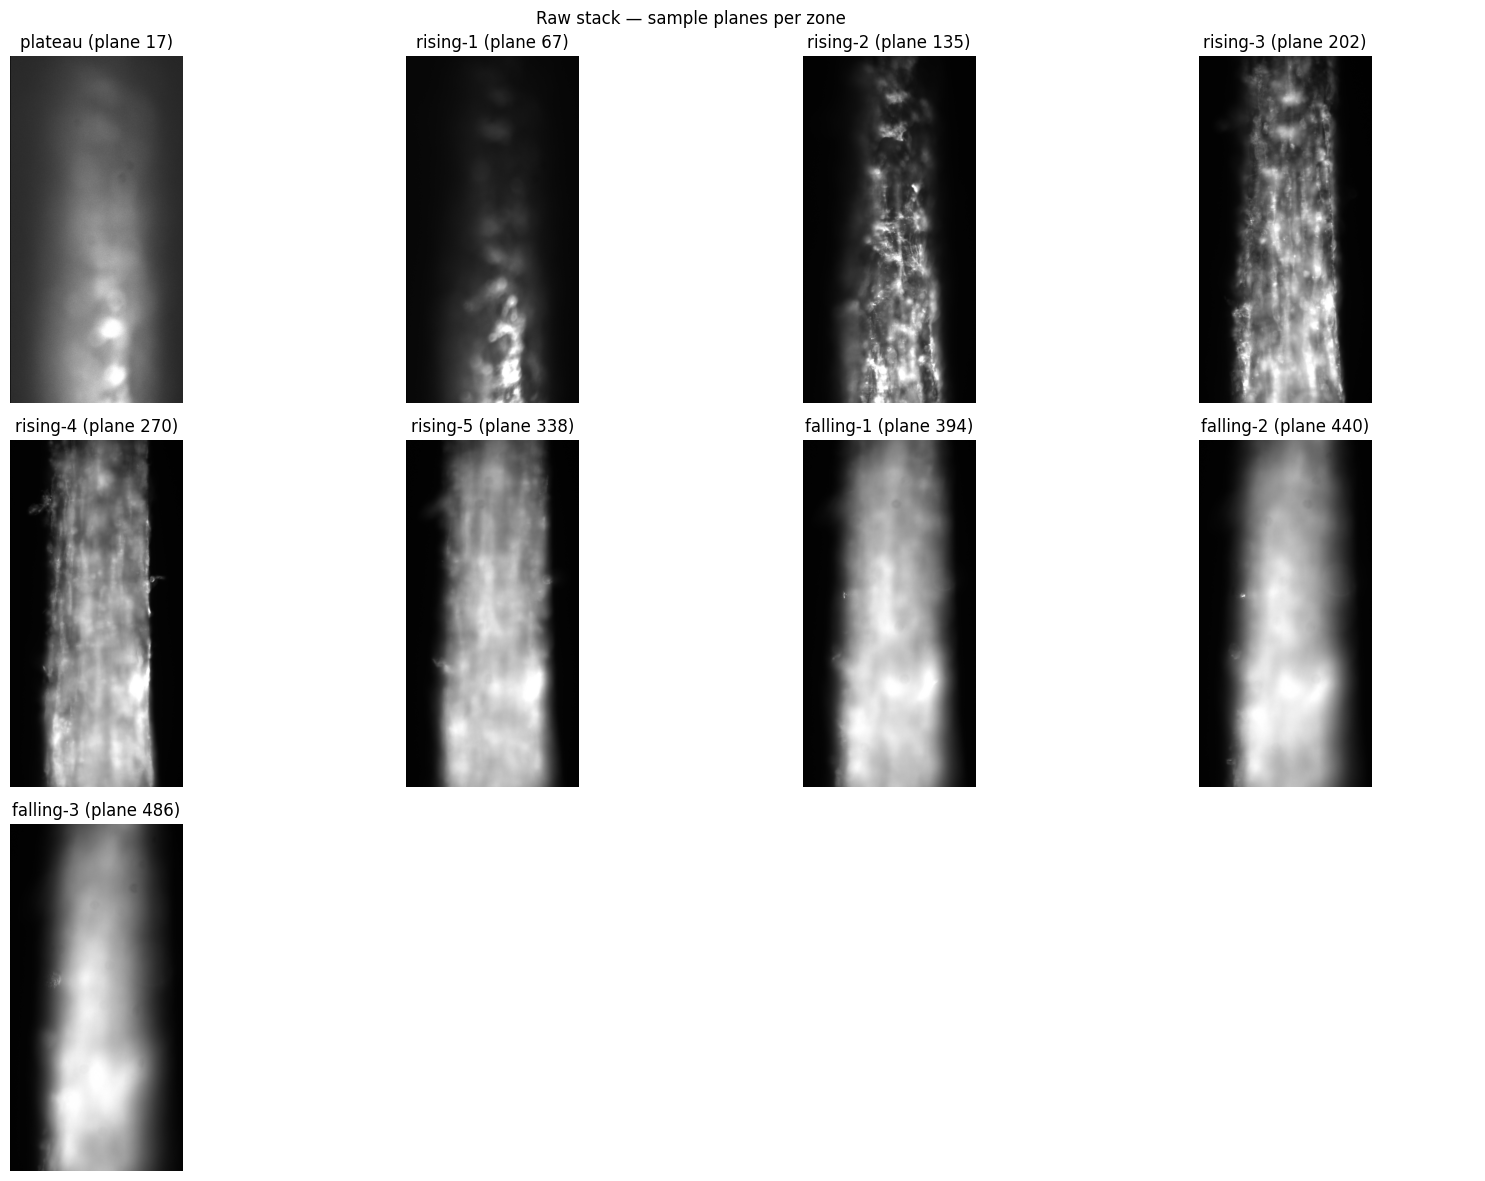

Recorded vs. computed intensity at each zone's sample plane (raw stack):


,zone_number,zone_label,sample_plane,sample_plane_intensity,computed_intensity_raw,diff,pct_diff
0,1,plateau,17,236.49,238.230797,1.740797,0.736098
1,2,rising-1,67,515.66,519.467567,3.807567,0.738387
2,3,rising-2,135,2222.98,2239.383478,16.403478,0.737905
3,4,rising-3,202,5335.92,5375.286092,39.366092,0.737756
4,5,rising-4,270,9162.24,9229.836723,67.596723,0.737775
5,6,rising-5,338,11514.37,11599.328719,84.958719,0.737849
6,7,falling-1,394,11384.69,11468.685495,83.995495,0.737793
7,8,falling-2,440,9689.39,9760.877635,71.487635,0.737793
8,9,falling-3,486,7286.28,7340.042986,53.762986,0.737866


In [5]:
plot_zone_grid(cnx_img, zone_samples, title="Raw stack — sample planes per zone")

raw_intensity = zone_intensity_table(cnx_img, zone_samples, 'computed_intensity_raw')
raw_comparison = zone_samples[['zone_number', 'zone_label', 'sample_plane', 'sample_plane_intensity']].merge(
    raw_intensity, on='zone_number'
)
raw_comparison['diff'] = raw_comparison['computed_intensity_raw'] - raw_comparison['sample_plane_intensity']
raw_comparison['pct_diff'] = 100 * raw_comparison['diff'] / raw_comparison['sample_plane_intensity']
print("Recorded vs. computed intensity at each zone's sample plane (raw stack):")
raw_comparison


## 4. Load background-removed image

Loads the rolling-ball background-subtracted stack saved by `1_1_preprocessing.ipynb`.
Path is relative to the `notebooks/` working directory, matching how it was saved.

In [6]:
bg_removed_path = Path( BASE_DIR / 'data' / 'preprocessed' / 'background_removed_img.tiff')
background_removed = io.imread(bg_removed_path)
print(f"Loaded background-removed stack: shape={background_removed.shape}, dtype={background_removed.dtype}")
print(f"  from {bg_removed_path.resolve()}")

if background_removed.shape != cnx_img.shape:
    print(f"WARNING: shape mismatch vs. raw stack {cnx_img.shape}")


Loaded background-removed stack: shape=(510, 2033, 1012), dtype=uint16
  from /home/rck292/Project/data/preprocessed/background_removed_img.tiff


## 5. QC of background removal

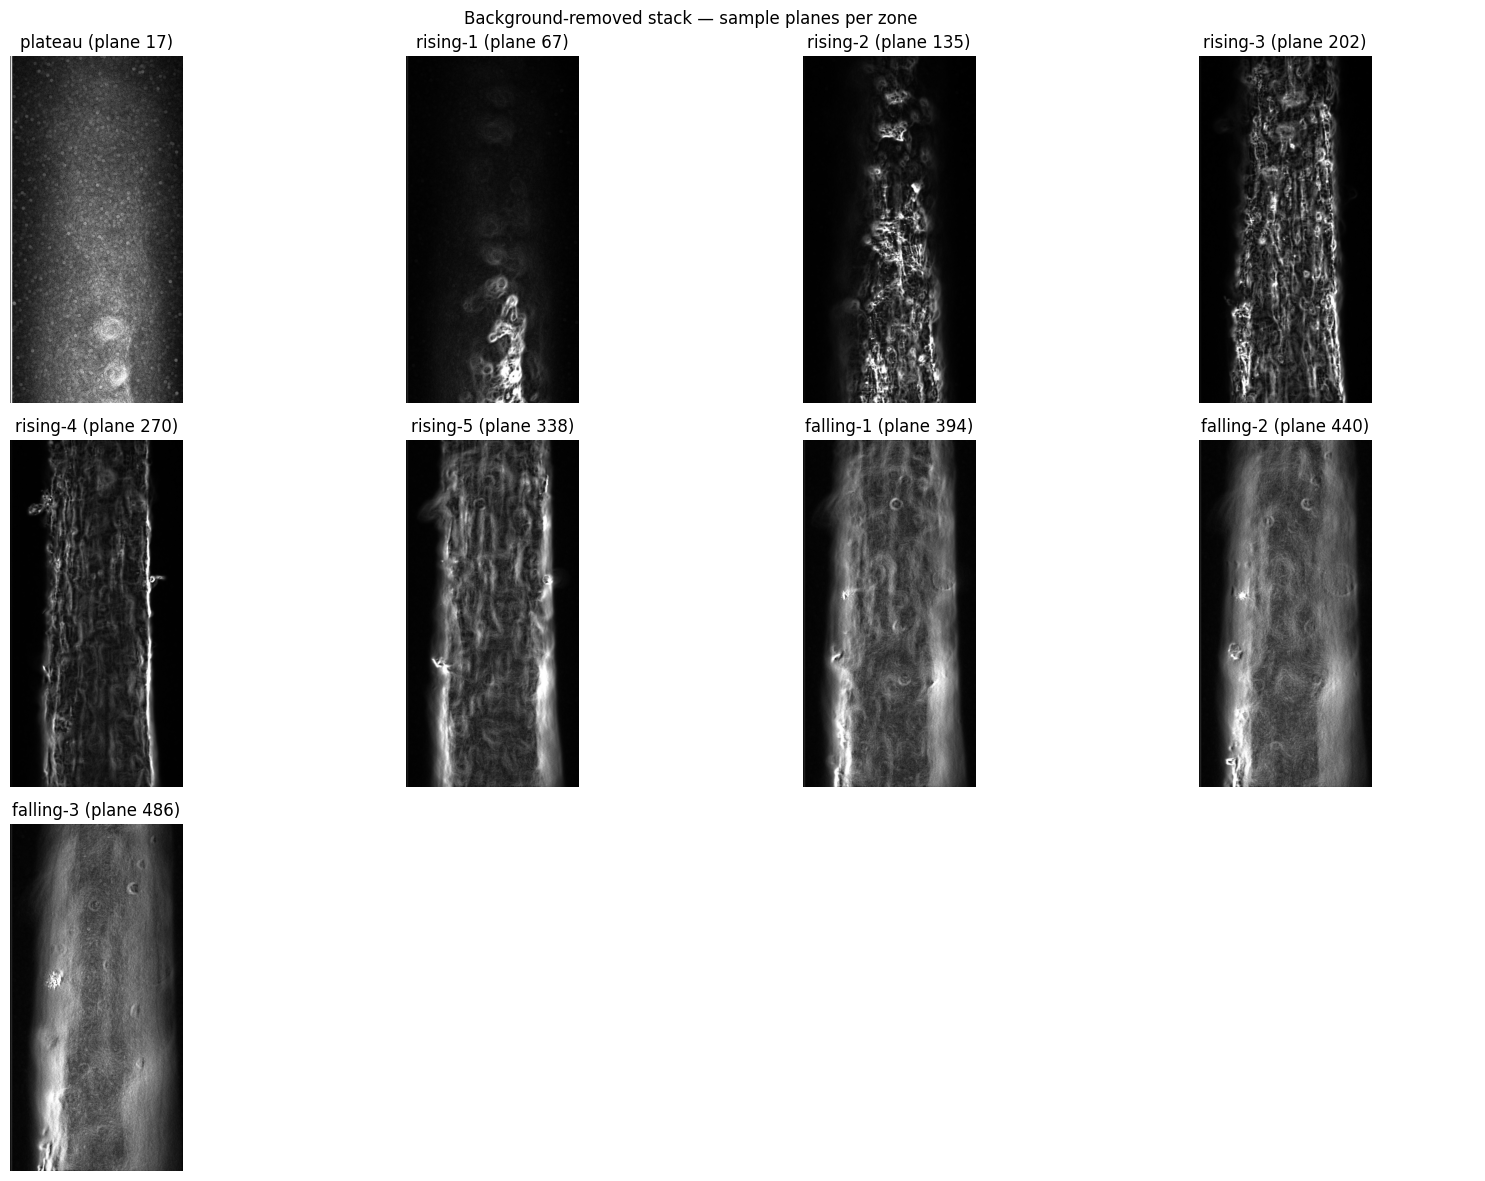

Per-zone intensity before/after background removal:


,zone_label,sample_plane,computed_intensity_raw,computed_intensity_bg_removed,pct_reduction
0,plateau,17,238.230797,34.060878,85.702571
1,rising-1,67,519.467567,79.900186,84.618831
2,rising-2,135,2239.383478,484.480775,78.365439
3,rising-3,202,5375.286092,840.989541,84.354516
4,rising-4,270,9229.836723,975.328211,89.432877
5,rising-5,338,11599.328719,765.772364,93.398132
6,falling-1,394,11468.685495,697.132511,93.921426
7,falling-2,440,9760.877635,594.566411,93.908679
8,falling-3,486,7340.042986,472.743979,93.559384


In [7]:
plot_zone_grid(background_removed, zone_samples, title="Background-removed stack — sample planes per zone")

bg_intensity = zone_intensity_table(background_removed, zone_samples, 'computed_intensity_bg_removed')
bg_comparison = raw_comparison.merge(bg_intensity, on='zone_number')
bg_comparison['pct_reduction'] = 100 * (
    bg_comparison['computed_intensity_raw'] - bg_comparison['computed_intensity_bg_removed']
) / bg_comparison['computed_intensity_raw']
print("Per-zone intensity before/after background removal:")
bg_comparison[['zone_label', 'sample_plane', 'computed_intensity_raw', 'computed_intensity_bg_removed', 'pct_reduction']]


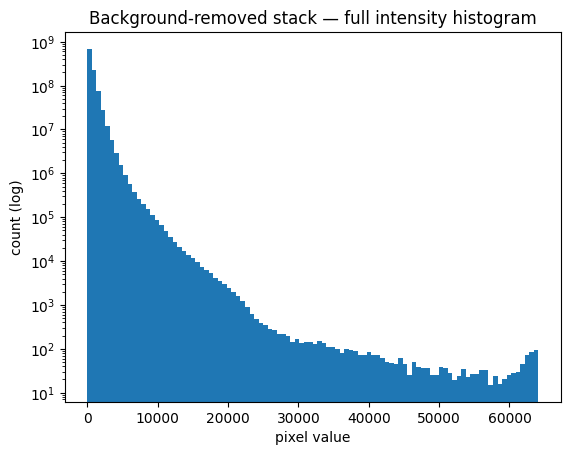

min=0, max=64068


In [8]:
plt.hist(background_removed.ravel(), bins=100)
plt.yscale('log')
plt.xlabel('pixel value')
plt.ylabel('count (log)')
plt.title('Background-removed stack — full intensity histogram')
plt.show()
print(f"min={background_removed.min()}, max={background_removed.max()}")


## 6. Load deconvolved image

Loads the PSF-centered Richardson-Lucy deconvolution output saved by
`1_1_preprocessing.ipynb`.

In [9]:
deconvolved_path = Path( BASE_DIR / 'data' / 'preprocessed' / 'background_removed_and_deconvolved_img.tiff')
deconvolved = io.imread(deconvolved_path)
print(f"Loaded deconvolved stack: shape={deconvolved.shape}, dtype={deconvolved.dtype}")
print(f"  from {deconvolved_path.resolve()}")

if deconvolved.shape != cnx_img.shape:
    print(f"WARNING: shape mismatch vs. raw stack {cnx_img.shape}")


Loaded deconvolved stack: shape=(510, 2033, 1012), dtype=float32
  from /home/rck292/Project/data/preprocessed/background_removed_and_deconvolved_img.tiff


## 7. Final QC — raw vs. background-removed vs. deconvolved

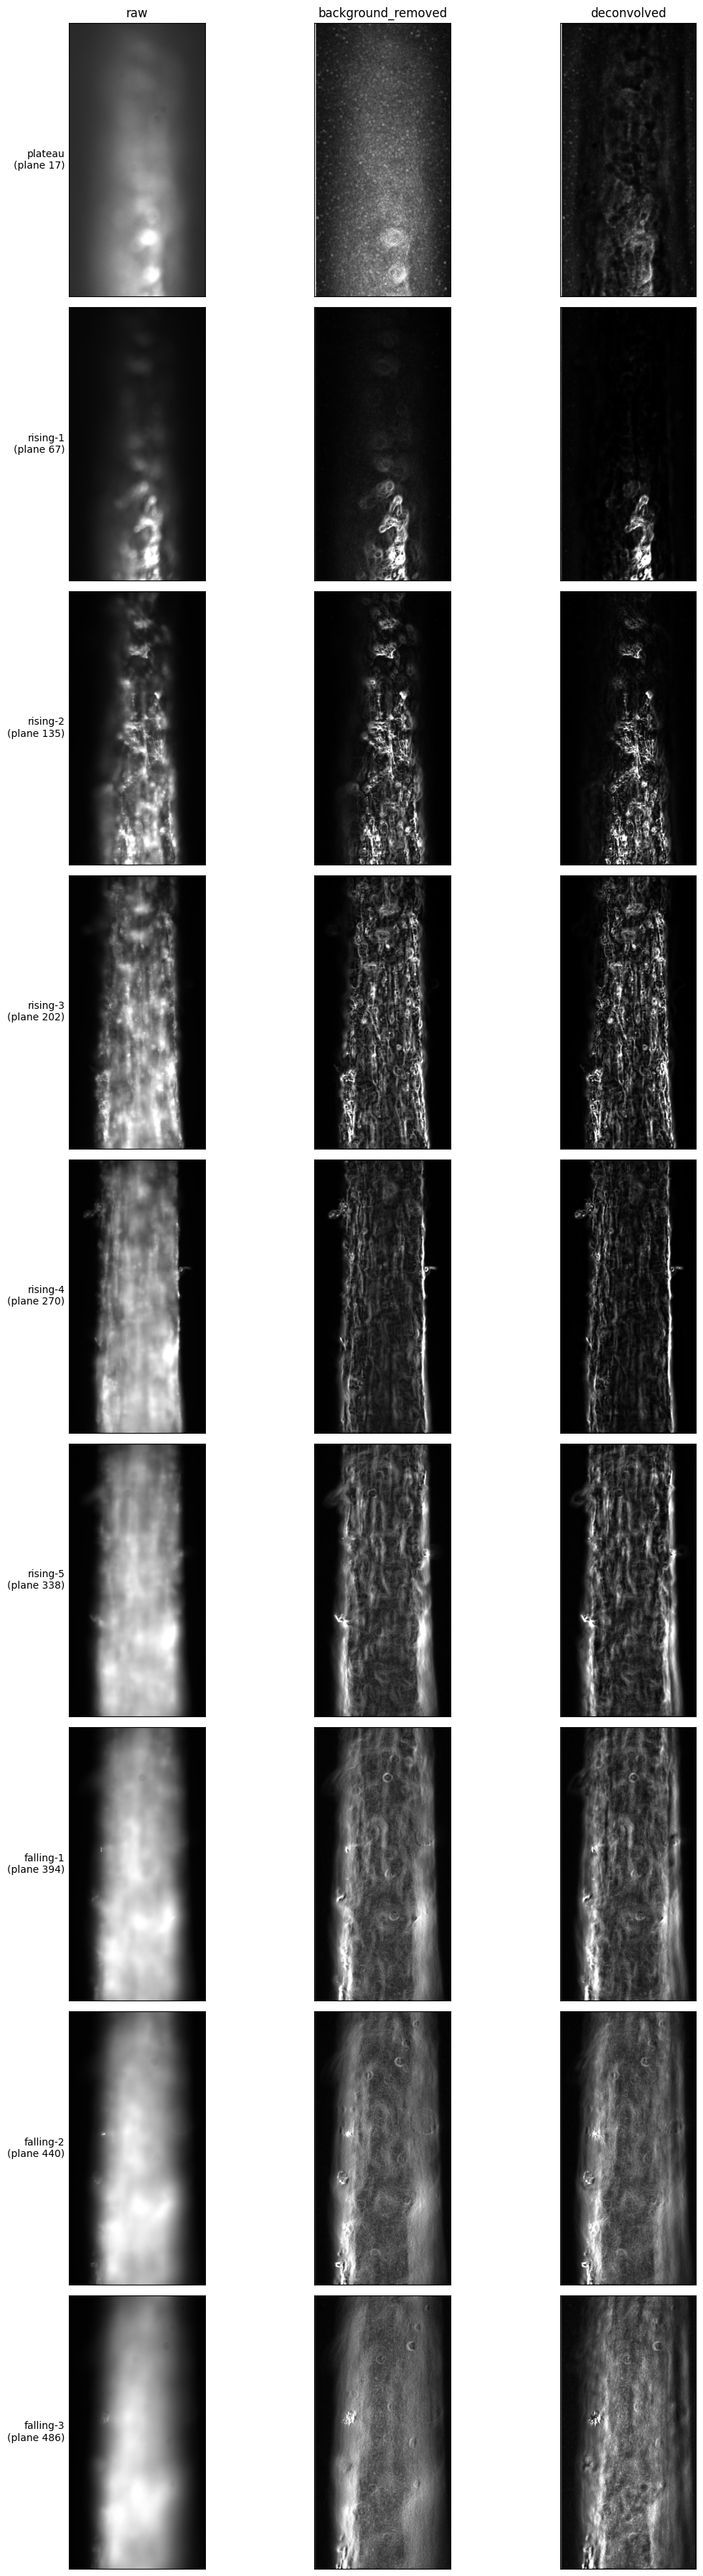

In [10]:
def plot_zone_stage_grid(stages, zone_df, cmap='gray', vmax_percentile=99.5):
    """Grid of (zone rows) x (pipeline stage columns) at each zone's sample_plane."""
    n_zones = len(zone_df)
    n_stages = len(stages)
    fig, axes = plt.subplots(n_zones, n_stages, figsize=(4 * n_stages, 4 * n_zones), squeeze=False)
    for i, (_, row) in enumerate(zone_df.iterrows()):
        plane = int(row['sample_plane'])
        for j, (stage_name, stage_stack) in enumerate(stages.items()):
            ax = axes[i, j]
            vmax = np.percentile(stage_stack[plane], vmax_percentile)
            ax.imshow(stage_stack[plane], cmap=cmap, vmax=vmax)
            if i == 0:
                ax.set_title(stage_name)
            if j == 0:
                ax.set_ylabel(f"{row['zone_label']}\n(plane {plane})", rotation=0, ha='right', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
    plt.tight_layout()
    plt.show()

stages = {
    'raw': cnx_img,
    'background_removed': background_removed,
    'deconvolved': deconvolved,
}
plot_zone_stage_grid(stages, zone_samples)


In [11]:
deconv_intensity = zone_intensity_table(deconvolved, zone_samples, 'computed_intensity_deconvolved')
final_summary = bg_comparison.merge(deconv_intensity, on='zone_number')
final_summary = final_summary[[
    'zone_number', 'zone_label', 'sample_plane', 'sample_plane_intensity',
    'computed_intensity_raw', 'computed_intensity_bg_removed', 'computed_intensity_deconvolved',
]]
print("Final per-zone intensity summary across all preprocessing stages:")
final_summary


Final per-zone intensity summary across all preprocessing stages:


,zone_number,zone_label,sample_plane,sample_plane_intensity,computed_intensity_raw,computed_intensity_bg_removed,computed_intensity_deconvolved
0,1,plateau,17,236.49,238.230797,34.060878,10.847297
1,2,rising-1,67,515.66,519.467567,79.900186,18.174713
2,3,rising-2,135,2222.98,2239.383478,484.480775,457.165375
3,4,rising-3,202,5335.92,5375.286092,840.989541,959.831421
4,5,rising-4,270,9162.24,9229.836723,975.328211,1006.119141
5,6,rising-5,338,11514.37,11599.328719,765.772364,711.343445
6,7,falling-1,394,11384.69,11468.685495,697.132511,712.921204
7,8,falling-2,440,9689.39,9760.877635,594.566411,814.417236
8,9,falling-3,486,7286.28,7340.042986,472.743979,241.798309


## Summary

This notebook only reads and QCs the full-stack outputs already produced by
`1_1_preprocessing.ipynb` — it does not recompute background removal or
deconvolution. The table in Section 7 gives the recorded vs. computed intensity at
every stage for each zone; large `pct_diff`/unexpected jumps there are the main
signal that the saved outputs don't match what's expected for a given zone.